In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)
x=np.random.rand(100,1)-0.5
y=3*x[:,0]**2+0.05*np.random.rand(100)

In [4]:
import pandas as pd
df=pd.DataFrame()

In [6]:
df['x']=x.reshape(100)
df['y']=y

In [7]:
df.head()

,x,y
0,-0.125460,0.048792
1,0.450714,0.641251
2,0.231994,0.177181
3,0.098658,0.054629
4,-0.343981,0.400348


In [8]:
df.shape

(100, 2)

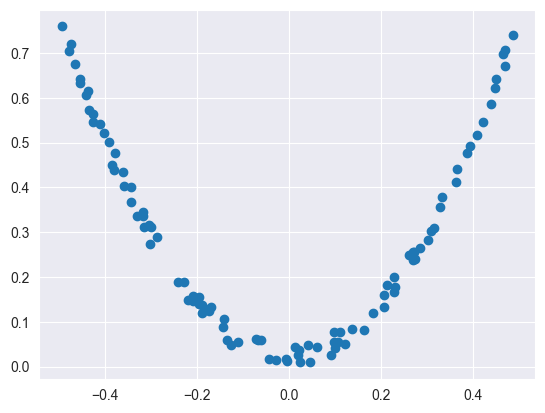

In [9]:
import matplotlib.pyplot as plt
plt.scatter(df['x'],df['y'])

In [10]:
df['pred1']=np.mean(x)

In [11]:
df

,x,y,pred1
0,-0.125460,0.048792,-0.029819
1,0.450714,0.641251,-0.029819
2,0.231994,0.177181,-0.029819
3,0.098658,0.054629,-0.029819
4,-0.343981,0.400348,-0.029819
...,...,...,...
95,-0.006204,0.017576,-0.029819
96,0.022733,0.037848,-0.029819
97,-0.072459,0.060606,-0.029819
98,-0.474581,0.720035,-0.029819


In [13]:
df['res1']=df['y']-df['pred1']

In [14]:
df

,x,y,pred1,res1
0,-0.125460,0.048792,-0.029819,0.078611
1,0.450714,0.641251,-0.029819,0.671070
2,0.231994,0.177181,-0.029819,0.207001
3,0.098658,0.054629,-0.029819,0.084448
4,-0.343981,0.400348,-0.029819,0.430167
...,...,...,...,...
95,-0.006204,0.017576,-0.029819,0.047395
96,0.022733,0.037848,-0.029819,0.067667
97,-0.072459,0.060606,-0.029819,0.090426
98,-0.474581,0.720035,-0.029819,0.749855


In [16]:
from sklearn.tree import DecisionTreeRegressor
tree1=DecisionTreeRegressor(max_leaf_nodes=8)
tree1.fit(df['x'].values.reshape(100,1),df['res1'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

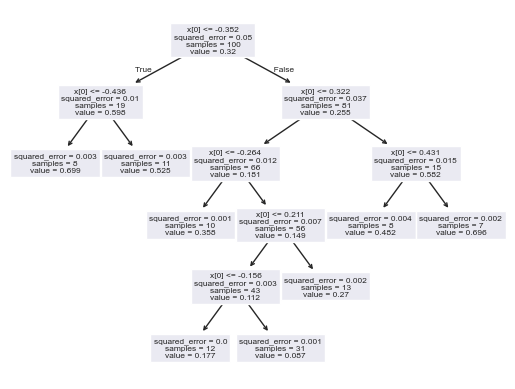

In [17]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [18]:
x_test=np.linspace(-0.5,0.5,500)


In [19]:
y_pred=-0.029819+tree1.predict(x_test.reshape(500,1))

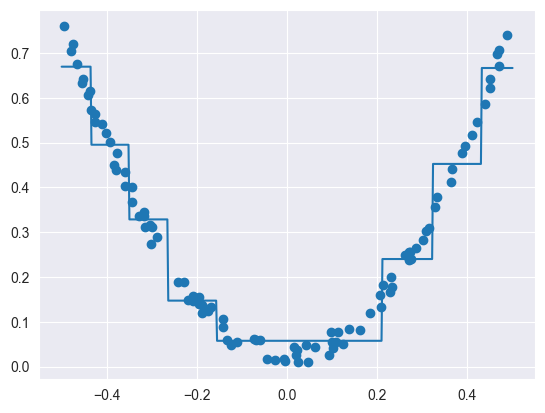

In [21]:
plt.scatter(df['x'],df['y'])
plt.plot(x_test,y_pred)

In [24]:
df['pred2']=-0.029819+tree1.predict(df['x'].values.reshape(100,1))